In [5]:
import pandas as pd

df = pd.read_csv("../data/raw/WELFake_Dataset.csv")

df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [6]:
df.shape
df.columns
df["label"].value_counts()
df.isnull().sum()

df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")
df = df.dropna(subset=["text"])
df.shape

df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df = df.drop(columns=["serial"], errors="ignore")

df.columns

Index(['title', 'text', 'label', 'content'], dtype='object')

In [7]:
df.to_csv("../data/processed/welfake_clean.csv", index=False)

df = pd.read_csv("../data/processed/welfake_clean.csv")

df.head()

,title,text,label,content
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...
1,NaN,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri..."
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...


In [8]:
X = df["content"]
y = df["label"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #ensure reproducibility-same split for every time
    stratify=y #keeps class balance consistent
)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.7 #too common words ignored
)

X_train_tfidf = vectorizer.fit_transform(X_train) #fit -learn vocab, transform - convert to matrix
X_test_tfidf = vectorizer.transform(X_test) #no use of fit here-test data must remain unseen

In [11]:
X_train_tfidf.shape

(57676, 220275)

In [12]:
#Train Logistic Regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_tfidf, y_train)

#make predictions
y_pred_lr = log_reg.predict(X_test_tfidf)

#eval model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9489562382966918

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7006
           1       0.94      0.96      0.95      7413

    accuracy                           0.95     14419
   macro avg       0.95      0.95      0.95     14419
weighted avg       0.95      0.95      0.95     14419



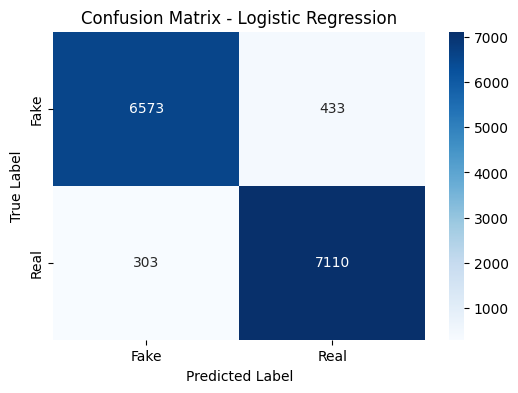

In [13]:
#confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [14]:
#ruajtja e modelit dhe vectorizer
import joblib

joblib.dump(log_reg, "../models/logistic_regression.pkl")
joblib.dump(vectorizer, "../models/tfidf_vectorizer.pkl")

['../models/tfidf_vectorizer.pkl']